
# Module 6 – Week 6: RC Circuit Modeling II (Design & Frequency Response)

**Course:** Research – Optimization with Calculus & Differential Equations  
**Focus:** Move from modeling to *design* and *system behavior*. You will (i) design an RC to meet a response-time spec, or (ii) measure its frequency response numerically to see **low‑pass filter** behavior.

## Learning Goals
- Translate a **time-domain spec** (10–90% rise time, $T_r$) into a choice of $R$ and $C$.  
- Use **parameter sweeps** and simple **grid search** to satisfy constraints.  
- Numerically measure **frequency response**: amplitude ratio vs frequency for $V_{in}(t)=V_0\sin(2\pi f t)$.  
- Explain how the **cutoff frequency** $f_c \approx \frac{1}{2\pi RC}$ relates to behavior.



## ✅ Pick ONE Problem (A or B)

**Problem A — Design from Rise‑Time Spec:**  
You need an RC that reaches 10–90% of its final value in $T_r$ seconds (rule of thumb: $T_r \approx 2.2\,\tau$ where $\tau=RC$).  
1) Choose from a set of available capacitors (e.g., $[0.10,0.22,0.47,1.0]\,\mu F$). For each $C$, compute the $R$ that hits $T_r$.  
2) Verify by simulating a step input with `solve_ivp`; measure the empirical 10–90% rise time.  
3) Report the pair $(R,C)$ that meets spec with smallest $|T_r^{\text{sim}}-T_r|$. Include a plot.

**Problem B — Frequency Response (Numerical Bode‑like):**  
For fixed $R,C$, simulate $V_{in}(t)=V_0\sin(2\pi f t)$ over a range of $f$.  
1) For each $f$, simulate several periods; use the **last period** to measure the **amplitude** of $V_C$.  
2) Plot amplitude ratio $A(f)=\frac{\text{amp}(V_C)}{\text{amp}(V_{in})}$ vs $f$ (log‑x).  
3) Estimate the **cutoff frequency** where $A(f)\approx \frac{1}{\sqrt{2}}$ and compare with $f_c=1/(2\pi RC)$.



## ✅ Submission Checklist
- [ ] Clear problem choice (A or B) and a short goal statement.  
- [ ] Working **code** (grid search or frequency sweep) with printed key numbers.  
- [ ] At least **one labeled plot** (time‑domain step or amplitude vs frequency).  
- [ ] Brief **reflection** (3–5 sentences) connecting results to \(\tau\) or \(f_c\).  
- [ ] Notebook runs top‑to‑bottom without errors.



## 1) Hand Reasoning (before coding)

**A: Rise‑time design.** Use $T_r \approx 2.2\,\tau\Rightarrow \tau \approx T_r/2.2$. For each candidate $C$, compute $R=\tau/C$.  
**B: Frequency response.** Low‑pass behavior means amplitude should drop as $f$ increases; the transition happens near $f_c=\frac{1}{2\pi RC}$.



## 2) SymPy (optional algebra)

Use SymPy to write the step response $V_C(t)=V_0(1-e^{-t/\tau})$ or to symbolically manipulate expressions you need. (Optional.)


In [2]:

# --- SymPy scratch (optional) ---
import sympy as sp
t, tau, V0 = sp.symbols('t tau V0', positive=True)
Vc = V0*(1-sp.exp(-t/tau))
sp.simplify(Vc)


V0 - V0*exp(-t/tau)


## 3) SciPy — Choose A or B


Best design:
  C = 1e-07 F
  R = 45454.545454545456 Ohm
  Tr_sim = 0.009984070997838207 s  (target = 0.01 s)
  abs error = 1.592900216179291e-05 s


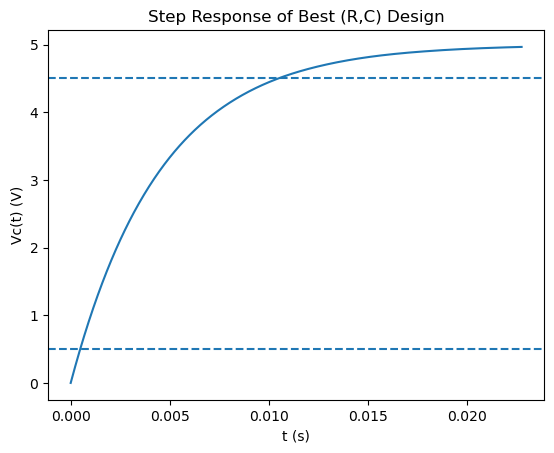

In [3]:

# --- Problem A: RC design from rise-time spec ---
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Target spec
Tr_target = 0.010  # 10 ms target 10-90% rise time
tau_target = Tr_target/2.2

# Candidate capacitors (Farads)
C_list = np.array([0.10e-6, 0.22e-6, 0.47e-6, 1.0e-6])
V0 = 5.0

def simulate_step(R, C):
    tau = R*C
    def rc_ode(t, Vc): return (V0 - Vc)/tau
    t_end = 5*tau if 5*tau>1e-3 else 1e-3  # at least 1ms
    t_eval = np.linspace(0, t_end, 800)
    sol = solve_ivp(rc_ode, (0.0, t_end), [0.0], t_eval=t_eval)
    t_arr, v_arr = sol.t, sol.y[0]
    v10, v90 = 0.1*V0, 0.9*V0
    # find first crossing times
    t10 = t_arr[np.argmax(v_arr>=v10)]
    t90 = t_arr[np.argmax(v_arr>=v90)]
    Tr = t90 - t10
    return t_arr, v_arr, Tr

results = []
for C in C_list:
    R = tau_target / C
    t_arr, v_arr, Tr_sim = simulate_step(R, C)
    err = abs(Tr_sim - Tr_target)
    results.append((C, R, Tr_sim, err, t_arr, v_arr))

# pick best
best = min(results, key=lambda x: x[3])
C_best, R_best, Tr_best, err_best, t_best, v_best = best
print("Best design:")
print("  C =", C_best, "F")
print("  R =", R_best, "Ohm")
print("  Tr_sim =", Tr_best, "s  (target =", Tr_target, "s)")
print("  abs error =", err_best, "s")

plt.figure()
plt.plot(t_best, v_best)
plt.axhline(0.1*V0, linestyle='--')
plt.axhline(0.9*V0, linestyle='--')
plt.xlabel("t (s)")
plt.ylabel("Vc(t) (V)")
plt.title("Step Response of Best (R,C) Design")
plt.show()


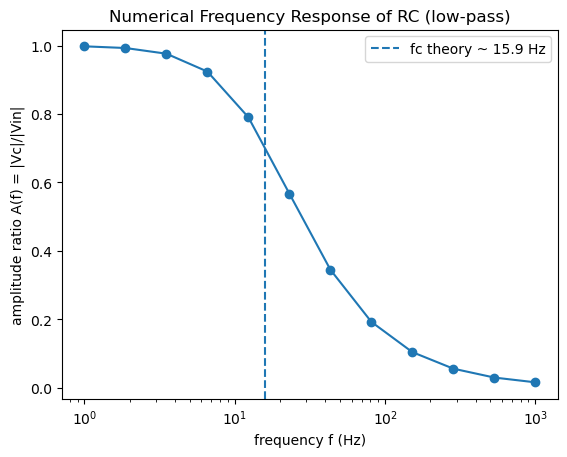

Theoretical cutoff fc ≈ 15.915494309189533 Hz


In [4]:

# --- Problem B: Frequency response by numerical simulation ---
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

R = 10_000.0    # Ohm
C = 1e-6        # F
V0 = 1.0        # sin amplitude
tau_val = R*C
fc_theory = 1.0/(2*np.pi*tau_val)

freqs = np.logspace(0, 3, 12)  # 1 Hz to 1000 Hz (12 points)
amp_ratios = []

def amp_last_period(y, t, f):
    T = 1.0/f
    mask = t >= (t[-1]-T)
    y_last = y[mask]
    return 0.5*(np.max(y_last) - np.min(y_last))

for f in freqs:
    T = 1.0/f
    t_end = max(10*T, 10*tau_val)   # ensure steady-ish state
    t_eval = np.linspace(0, t_end, int(800 + 40*f))  # more points for higher f
    
    def Vin(t): return V0*np.sin(2*np.pi*f*t)
    def rc_ode(t, Vc): return (Vin(t) - Vc)/tau_val
    
    sol = solve_ivp(rc_ode, (0.0, t_end), [0.0], t_eval=t_eval, rtol=1e-6, atol=1e-8)
    Aout = amp_last_period(sol.y[0], sol.t, f)
    Ain  = V0  # sine amplitude
    amp_ratios.append(Aout/Ain)

plt.figure()
plt.semilogx(freqs, amp_ratios, marker='o')
plt.axvline(fc_theory, linestyle='--', label=f"fc theory ~ {fc_theory:.1f} Hz")
plt.xlabel("frequency f (Hz)")
plt.ylabel("amplitude ratio A(f) = |Vc|/|Vin|")
plt.title("Numerical Frequency Response of RC (low-pass)")
plt.legend()
plt.show()

print("Theoretical cutoff fc ≈", fc_theory, "Hz")



## 4) Reflection (3–5 sentences)
- **A:** How close did your simulated \(T_r\) come to the target? Which capacitor gave the best trade‑off?  
- **B:** Where did your amplitude ratio get close to \(1/\sqrt{2}\)? How does that compare with \(f_c=1/(2\pi RC)\)?


In [ ]:
A, the simulated T_r came 0.000026 of the theoretical T_r. The capacitor that gave the best trade-off was the 10e-6 one.
B, the amplitude ratio go close to 1/(sqrt(2)) when it approached near 16 Hz. This compares with f_c = 1/(2piRC) because it is equal to the same value.